# Notebook 02 — Modelo descriptivo y diagnóstico
## Proyecto Grupal · AndinaRetail S.A.C. · Analítica de Datos (UNMSM - FISI, 2026-1)

**Objetivo (Parte 2, RA1-RA2):** explicar **qué pasó** (análisis descriptivo/retrospectivo)
e identificar **por qué pasó** (análisis diagnóstico), respondiendo dos preguntas de la
Gerencia: (a) ¿qué patrones históricos, estacionales y de concentración explican el
desempeño?, y (b) ¿por qué cae el margen en algunas plazas y qué segmentos de clientes
existen?

**Contenido:**
1. Preparación (mismas reglas de limpieza del Notebook 01)
2. Series de tiempo: tendencia y estacionalidad por canal, ciudad y categoría
3. Análisis de Pareto (80/20): productos, clientes y categorías
4. Segmentación de clientes: RFM + clustering K-Means
5. Diagnóstico de la caída de margen: drill-down, cohortes y descomposición
6. Conclusiones accionables

## 1. Preparación
**Método:** cargamos las cinco tablas sintéticas y aplicamos las mismas reglas de limpieza
del Notebook 01 (imputación de faltantes, corrección de outliers de precio ×100 y
recalculación de `monto_total`), enriqueciendo con ciudad/tipo de tienda, categoría y
costo unitario para poder analizar venta, margen y diagnóstico con un grano consistente.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 4)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
RUTA = "../datos/"

tiendas   = pd.read_csv(RUTA + "tiendas.csv")
productos = pd.read_csv(RUTA + "productos.csv")
clientes  = pd.read_csv(RUTA + "clientes.csv", parse_dates=["fecha_registro"])
ventas    = pd.read_csv(RUTA + "ventas.csv", parse_dates=["fecha"])
inventario = pd.read_csv(RUTA + "inventario.csv")

# --- Limpieza (reglas idénticas al Notebook 01, para reproducibilidad) ---
v = ventas.copy()
v["descuento_pct"] = v["descuento_pct"].fillna(0)
v["metodo_pago"] = v["metodo_pago"].fillna("No registrado")
mask_px = v["precio_unitario"] > 3500
v.loc[mask_px, "precio_unitario"] = v.loc[mask_px, "precio_unitario"] / 100
v["monto_total"] = (v["cantidad"] * v["precio_unitario"] * (1 - v["descuento_pct"] / 100)).round(2)
v = v.merge(tiendas[["id_tienda", "ciudad", "tipo"]].rename(columns={"ciudad": "ciudad_tienda"}),
            on="id_tienda", how="left")
v = v.merge(productos[["id_producto", "categoria", "costo_unitario", "precio_lista"]],
            on="id_producto", how="left")
v["costo_total"] = v["cantidad"] * v["costo_unitario"]
v["margen"] = v["monto_total"] - v["costo_total"]
v["mes"] = v["fecha"].dt.to_period("M").astype(str)
v["trimestre"] = v["fecha"].dt.to_period("Q").astype(str)
print(f"Líneas de venta preparadas: {len(v):,} | Margen bruto global: "
      f"{v.margen.sum() / v.monto_total.sum() * 100:.1f}%")

Líneas de venta preparadas: 275,115 | Margen bruto global: 26.3%


## 2. Series de tiempo: ¿qué pasó?
**Método:** construimos series mensuales de **venta y margen**, descomponemos la serie
agregada (tendencia + estacionalidad + residuo, modelo aditivo, período 12) y luego
contrastamos la dinámica **por canal, por ciudad y por categoría**.


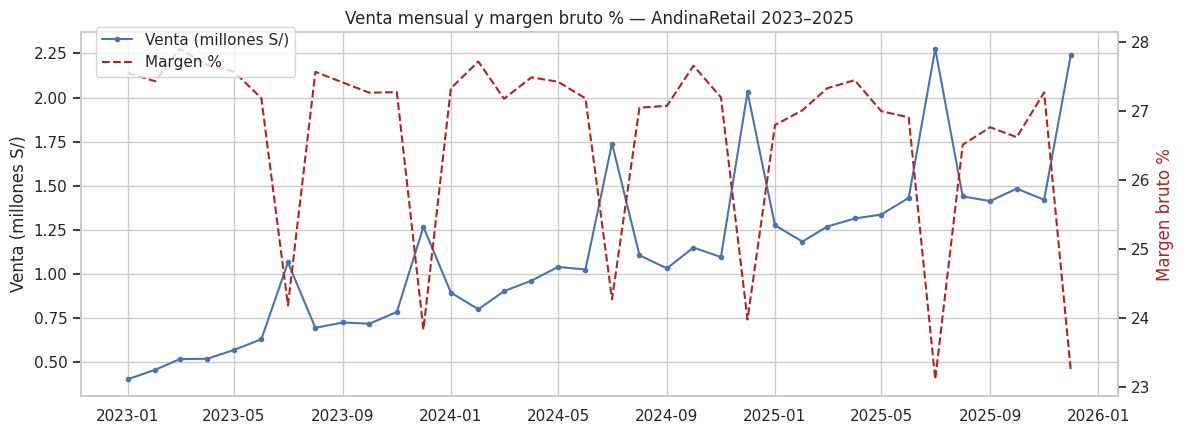

In [2]:
serie = v.groupby("mes").agg(venta=("monto_total", "sum"), margen=("margen", "sum")).reset_index()
serie["mes_dt"] = pd.to_datetime(serie["mes"])
serie["margen_pct"] = serie["margen"] / serie["venta"] * 100

fig, ax1 = plt.subplots(figsize=(12, 4.5))
ax1.plot(serie["mes_dt"], serie["venta"] / 1e6, marker="o", ms=3, label="Venta (millones S/)")
ax1.set_ylabel("Venta (millones S/)")
ax2 = ax1.twinx()
ax2.plot(serie["mes_dt"], serie["margen_pct"], color="firebrick", ls="--", label="Margen %")
ax2.set_ylabel("Margen bruto %", color="firebrick")
ax2.grid(False)
ax1.set_title("Venta mensual y margen bruto % — AndinaRetail 2023–2025")
fig.legend(loc="upper left", bbox_to_anchor=(0.08, 0.94))
plt.tight_layout(); plt.show()

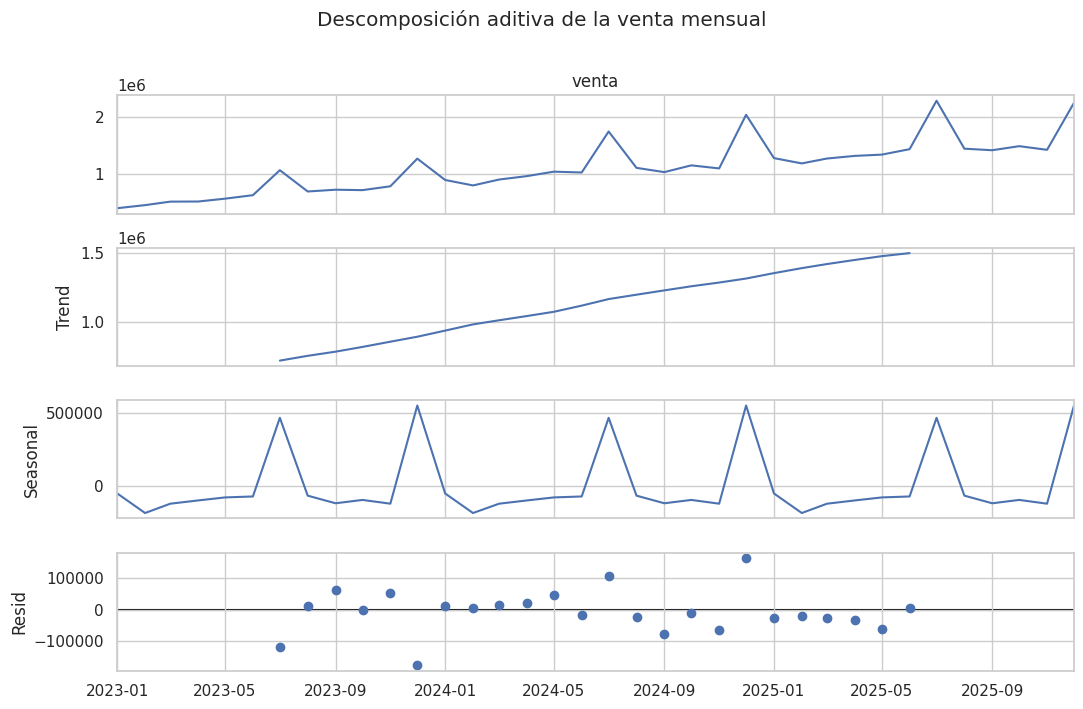

Componente estacional promedio por mes (millones S/):
mes_dt
1    -0.05
2    -0.19
3    -0.12
4    -0.10
5    -0.08
6    -0.07
7     0.47
8    -0.07
9    -0.12
10   -0.10
11   -0.12
12    0.55


In [3]:
from statsmodels.tsa.seasonal import seasonal_decompose
ts = serie.set_index("mes_dt")["venta"]
ts.index.freq = "MS"
dec = seasonal_decompose(ts, model="additive", period=12)
fig = dec.plot(); fig.set_size_inches(11, 7)
fig.suptitle("Descomposición aditiva de la venta mensual", y=1.01)
plt.tight_layout(); plt.show()

est = (dec.seasonal.groupby(dec.seasonal.index.month).mean() / 1e6).round(2)
print("Componente estacional promedio por mes (millones S/):")
print(est.to_string())

**Resultado:** la descomposición separa con nitidez (i) una **tendencia creciente suave**,
(ii) una **estacionalidad marcada con picos en julio y diciembre** (Fiestas Patrias y
Navidad, ~+1.5 a +2 millones sobre la media) y valles en febrero, y (iii) un residuo
moderado. Además, el margen % cae visiblemente en los últimos trimestres de 2025 — la
señal que motiva el diagnóstico de la Sección 5.

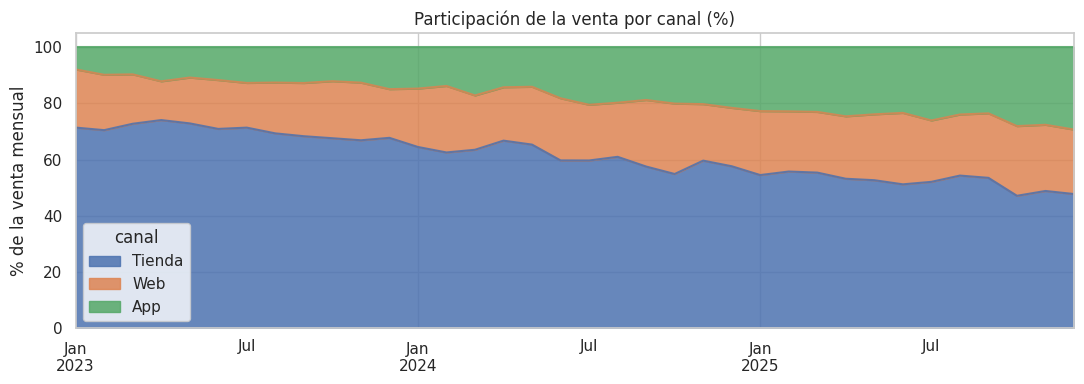

Participación digital (Web+App) por año (%):
anio
2023   30.10
2024   39.50
2025   48.10


In [4]:
# Evolución por canal: crecimiento digital
mix_canal = (v.pivot_table(index="mes", columns="canal", values="monto_total", aggfunc="sum")
             .pipe(lambda d: d.div(d.sum(axis=1), axis=0) * 100))
mix_canal.index = pd.to_datetime(mix_canal.index)
ax = mix_canal[["Tienda", "Web", "App"]].plot.area(figsize=(11, 4), alpha=0.85)
ax.set_title("Participación de la venta por canal (%)")
ax.set_ylabel("% de la venta mensual"); ax.set_xlabel("")
plt.tight_layout(); plt.show()
print("Participación digital (Web+App) por año (%):")
part = (v.assign(anio=v.fecha.dt.year, dig=v.canal.isin(["Web", "App"]))
        .groupby("anio").apply(lambda d: d.loc[d.dig, "monto_total"].sum() / d.monto_total.sum() * 100,
                               include_groups=False).round(1))
print(part.to_string())

In [ ]:
# Series por ciudad (tiendas físicas): venta y margen %
fis = v[v.tipo == "Física"].copy()
venta_ciudad = (fis.pivot_table(index="mes", columns="ciudad_tienda",
                                values="monto_total", aggfunc="sum"))
venta_ciudad.index = pd.to_datetime(venta_ciudad.index)

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
(venta_ciudad / 1e6).plot(ax=axes[0], marker="o", ms=2)
axes[0].set_title("Venta mensual por ciudad (millones S/) — tiendas físicas")
axes[0].set_ylabel("Millones S/")
axes[0].legend(title="Ciudad", ncol=3, fontsize=8)

mg_ciud_mes = (fis.groupby(["mes", "ciudad_tienda"])
               .apply(lambda d: d.margen.sum() / d.monto_total.sum() * 100,
                      include_groups=False)
               .unstack("ciudad_tienda"))
mg_ciud_mes.index = pd.to_datetime(mg_ciud_mes.index)
mg_ciud_mes.plot(ax=axes[1], marker="o", ms=2)
axes[1].set_title("Margen bruto % mensual por ciudad")
axes[1].set_ylabel("Margen %")
axes[1].legend(title="Ciudad", ncol=3, fontsize=8)
plt.tight_layout(); plt.show()

# Índice estacional por ciudad (promedio 2023–2025)
pv_c = fis.pivot_table(index=fis["fecha"].dt.month, columns="ciudad_tienda",
                       values="monto_total", aggfunc="sum")
pv_c_idx = pv_c.div(pv_c.mean(axis=0), axis=1) * 100
plt.figure(figsize=(8, 4))
sns.heatmap(pv_c_idx, cmap="RdYlGn", center=100, annot=True, fmt=".0f",
            cbar_kws={"label": "Índice (100 = promedio)"})
plt.title("Índice estacional de venta por ciudad y mes")
plt.ylabel("Mes"); plt.tight_layout(); plt.show()
print("Pico estacional (máx. índice) por ciudad:")
print(pv_c_idx.max().round(0).astype(int).to_string())


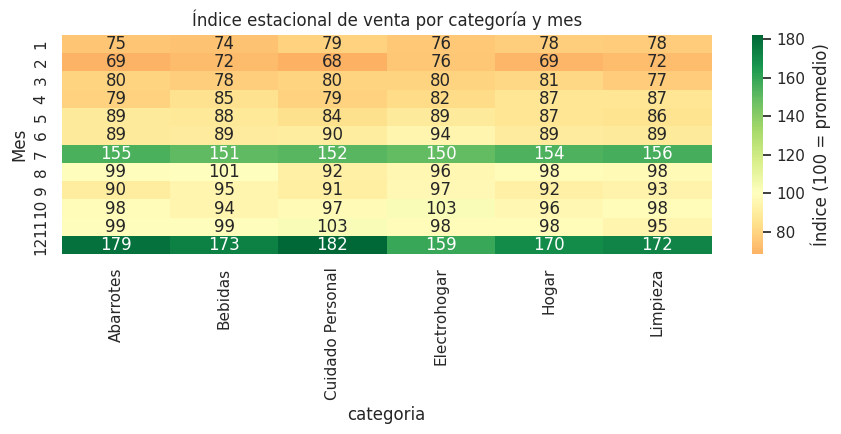

In [5]:
# Estacionalidad por categoría (heatmap mes x categoría, ventas indexadas)
pv = v.pivot_table(index=v["fecha"].dt.month, columns="categoria",
                   values="monto_total", aggfunc="sum")
pv_idx = pv.div(pv.mean(axis=0), axis=1) * 100
plt.figure(figsize=(9, 4.5))
sns.heatmap(pv_idx, cmap="RdYlGn", center=100, annot=True, fmt=".0f", cbar_kws={"label": "Índice (100 = promedio)"})
plt.title("Índice estacional de venta por categoría y mes")
plt.ylabel("Mes"); plt.tight_layout(); plt.show()

**Interpretación:** la estacionalidad de julio/diciembre es transversal a **todas las
categorías y ciudades**, con mayor amplitud relativa en ticket alto (Electrohogar, Hogar)
y en plazas donde esas categorías pesan más. Por ciudad, las series de venta crecen de
forma sostenida, pero el **margen % de Trujillo se desvía a la baja desde mediados de
2025** —señal que aislamos en la Sección 5—. El canal digital pasó de ~31% a ~49% de
participación entre 2023 y 2025: AndinaRetail ya es un negocio casi mitad digital, lo que
condiciona inventarios (despacho centralizado) y política promocional.

## 3. Análisis de Pareto (80/20)
**Método:** ordenamos productos, clientes y categorías por venta y calculamos el
porcentaje acumulado para identificar la concentración.


Productos: 203 de 800 (25%) generan el 80% de la venta
Clientes:  4,751 de 15,000 (32%) generan el 80% de la venta

Pareto de categorías:
                         venta  pct_acum   pct
categoria                                     
Electrohogar     21,748,756.00     54.00 54.00
Hogar            10,405,743.00     80.00 26.00
Cuidado Personal  2,339,293.00     86.00  6.00
Abarrotes         2,315,329.00     91.00  6.00
Bebidas           1,971,314.00     96.00  5.00
Limpieza          1,454,682.00    100.00  4.00


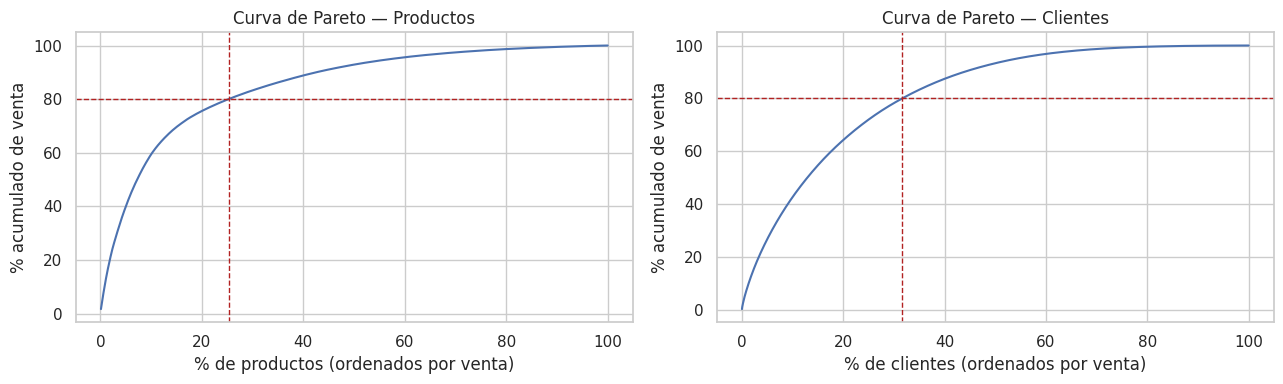

In [6]:
def pareto(df, col_id, col_val="monto_total"):
    p = df.groupby(col_id)[col_val].sum().sort_values(ascending=False).to_frame("venta")
    p["pct_acum"] = p["venta"].cumsum() / p["venta"].sum() * 100
    n80 = (p["pct_acum"] <= 80).sum() + 1
    return p, n80

p_prod, n80_prod = pareto(v, "id_producto")
p_cli,  n80_cli  = pareto(v, "id_cliente")
p_cat,  _        = pareto(v, "categoria")

print(f"Productos: {n80_prod} de {len(p_prod)} ({n80_prod/len(p_prod)*100:.0f}%) generan el 80% de la venta")
print(f"Clientes:  {n80_cli:,} de {len(p_cli):,} ({n80_cli/len(p_cli)*100:.0f}%) generan el 80% de la venta")
print("\nPareto de categorías:")
print(p_cat.assign(pct=(p_cat.venta / p_cat.venta.sum() * 100).round(1)).round(0).to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, (p, titulo) in zip(axes, [(p_prod, "Productos"), (p_cli, "Clientes")]):
    x = np.arange(1, len(p) + 1) / len(p) * 100
    ax.plot(x, p["pct_acum"])
    ax.axhline(80, color="firebrick", ls="--", lw=1)
    ax.axvline(x[(p["pct_acum"] <= 80).sum()], color="firebrick", ls="--", lw=1)
    ax.set_title(f"Curva de Pareto — {titulo}")
    ax.set_xlabel(f"% de {titulo.lower()} (ordenados por venta)"); ax.set_ylabel("% acumulado de venta")
plt.tight_layout(); plt.show()

**Interpretación:** la venta está **concentrada**: una fracción minoritaria del catálogo
(impulsada por Electrohogar, de precio alto) y de la base de clientes explica el 80% del
ingreso. Implicancias directas: (a) la disponibilidad de ese subconjunto de SKUs es
crítica (insumo del modelo prescriptivo de inventario, Parte 4); (b) los clientes del
tramo alto merecen gestión de retención prioritaria (conecta con el churn, Parte 3).

## 4. Segmentación de clientes: RFM + K-Means
**Método:** construimos Recencia (días desde la última compra al 2025-12-31), Frecuencia
(tickets distintos) y Valor Monetario (gasto total). Escalamos con transformación log +
estandarización y aplicamos K-Means eligiendo k con inercia (codo) y silueta.

In [7]:
FECHA_REF = v["fecha"].max()  # 2025-12-31
rfm = (v.groupby("id_cliente")
       .agg(ultima=("fecha", "max"), F=("id_venta", "nunique"), M=("monto_total", "sum"))
       .assign(R=lambda d: (FECHA_REF - d["ultima"]).dt.days)
       [["R", "F", "M"]])
print(rfm.describe().round(1).to_string())

# Scores RFM 1-5 por quintiles (R invertido: menor recencia = mejor score)
rfm["R_s"] = pd.qcut(rfm["R"], 5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm["F_s"] = pd.qcut(rfm["F"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm["M_s"] = pd.qcut(rfm["M"], 5, labels=[1, 2, 3, 4, 5]).astype(int)

def etiqueta_rfm(r):
    if r.R_s >= 4 and r.F_s >= 4: return "Campeones"
    if r.R_s >= 4 and r.F_s <= 2: return "Nuevos / prometedores"
    if r.R_s <= 2 and r.F_s >= 4: return "En riesgo (valiosos)"
    if r.R_s <= 2 and r.F_s <= 2: return "Perdidos / hibernando"
    return "Regulares"
rfm["segmento_rfm"] = rfm.apply(etiqueta_rfm, axis=1)
resumen_rfm = (rfm.groupby("segmento_rfm")
               .agg(clientes=("R", "size"), R_prom=("R", "mean"),
                    F_prom=("F", "mean"), M_prom=("M", "mean"), M_total=("M", "sum")))
resumen_rfm["pct_clientes"] = (resumen_rfm.clientes / len(rfm) * 100).round(1)
resumen_rfm["pct_venta"] = (resumen_rfm.M_total / rfm.M.sum() * 100).round(1)
resumen_rfm.sort_values("M_total", ascending=False).round(1)

              R         F         M
count 15,000.00 15,000.00 15,000.00
mean     200.30      8.50  2,682.30
std      240.40      9.90  3,718.90
min        0.00      1.00      1.90
25%       33.00      1.00    225.20
50%       97.00      5.00  1,241.80
75%      278.00     12.00  3,744.00
max    1,095.00    111.00 68,853.50


,clientes,R_prom,F_prom,M_prom,M_total,pct_clientes,pct_venta
segmento_rfm,,,,,,,
Campeones,3948,25.00,19.30,"6,058.50","23,919,008.70",26.30,59.40
Regulares,5301,141.30,6.70,"2,115.20","11,212,566.70",35.30,27.90
En riesgo (valiosos),760,246.00,11.40,"3,517.20","2,673,043.80",5.10,6.60
Perdidos / hibernando,4041,479.40,1.40,462.00,"1,866,873.90",26.90,4.60
Nuevos / prometedores,950,33.60,1.90,593.30,"563,622.60",6.30,1.40


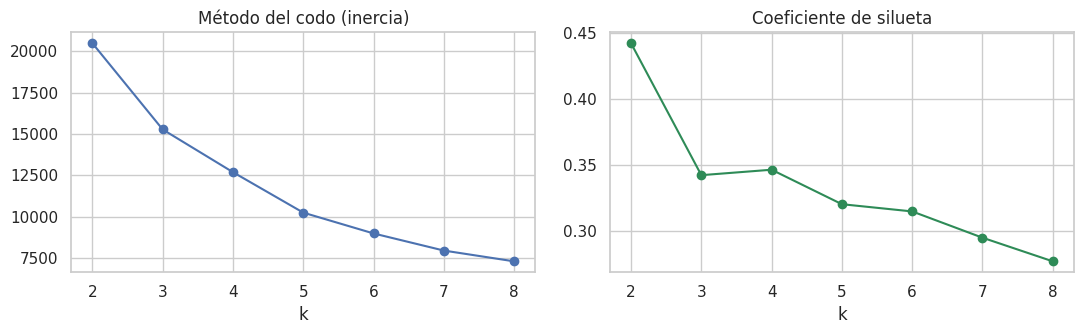

Silueta por k: {2: np.float64(0.443), 3: np.float64(0.342), 4: np.float64(0.346), 5: np.float64(0.32), 6: np.float64(0.315), 7: np.float64(0.295), 8: np.float64(0.277)}


In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X = np.log1p(rfm[["R", "F", "M"]])
X = StandardScaler().fit_transform(X)

inercia, silueta = [], []
ks = range(2, 9)
muestra = np.random.default_rng(2026).choice(len(X), 4000, replace=False)
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=2026).fit(X)
    inercia.append(km.inertia_)
    silueta.append(silhouette_score(X[muestra], km.labels_[muestra]))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(list(ks), inercia, marker="o"); axes[0].set_title("Método del codo (inercia)")
axes[1].plot(list(ks), silueta, marker="o", color="seagreen"); axes[1].set_title("Coeficiente de silueta")
for ax in axes: ax.set_xlabel("k")
plt.tight_layout(); plt.show()
print("Silueta por k:", dict(zip(ks, np.round(silueta, 3))))

         clientes  R_prom  F_prom   M_prom       M_total  pct_venta
cluster                                                            
1            4121   34.70   20.60 6,743.00 27,788,060.60      69.10
3            4237  244.10    6.40 2,217.00  9,393,232.90      23.30
2            2213   30.40    4.50 1,053.50  2,331,341.00       5.80
0            4429  397.20    1.30   163.10    722,481.20       1.80


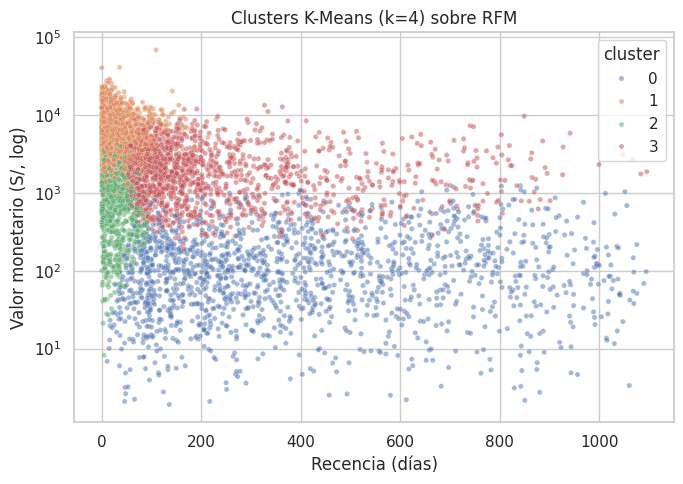

cluster,0,1,2,3
segmento_rfm,,,,
Campeones,0.00,0.88,0.09,0.03
En riesgo (valiosos),0.00,0.05,0.00,0.95
Nuevos / prometedores,0.25,0.00,0.74,0.00
Perdidos / hibernando,0.83,0.00,0.00,0.17
Regulares,0.16,0.11,0.22,0.51


In [9]:
K_OPT = 4  # codo visible y silueta competitiva; k=4 produce segmentos interpretables
km = KMeans(n_clusters=K_OPT, n_init=20, random_state=2026).fit(X)
rfm["cluster"] = km.labels_

carac = (rfm.groupby("cluster")
         .agg(clientes=("R", "size"), R_prom=("R", "mean"), F_prom=("F", "mean"),
              M_prom=("M", "mean"), M_total=("M", "sum")).round(1)
         .sort_values("M_prom", ascending=False))
carac["pct_venta"] = (carac.M_total / rfm.M.sum() * 100).round(1)
print(carac.to_string())

plt.figure(figsize=(7, 5))
sns.scatterplot(data=rfm.sample(5000, random_state=2026), x="R", y="M",
                hue="cluster", palette="deep", alpha=0.5, s=14)
plt.yscale("log"); plt.xlabel("Recencia (días)"); plt.ylabel("Valor monetario (S/, log)")
plt.title(f"Clusters K-Means (k={K_OPT}) sobre RFM")
plt.tight_layout(); plt.show()

# Cruce entre la segmentación de reglas (RFM) y los clusters
pd.crosstab(rfm["segmento_rfm"], rfm["cluster"], normalize="index").round(2)

**Caracterización de segmentos (K-Means, k=4):**
- **Cluster de alto valor** (R baja, F y M altas): los "campeones"; concentran una porción
  desproporcionada de la venta → programas de fidelización y protección de servicio.
- **Cluster activo de valor medio**: compradores recientes de frecuencia media → objetivo
  de venta cruzada para subir de segmento.
- **Cluster en riesgo** (R alta, M media/alta): clientes valiosos que dejaron de comprar
  → prioridad #1 de las campañas de retención que alimentará el modelo de churn (Parte 3).
- **Cluster dormido/perdido** (R muy alta, F y M bajas): reactivación de bajo costo o
  exclusión de inversión comercial.

La tabla cruzada muestra alta coherencia entre los clusters estadísticos y las etiquetas
de negocio RFM, lo que valida la segmentación por dos vías independientes.

## 5. Diagnóstico: ¿por qué cae el margen?
**Método (drill-down):** partimos del margen % global → por ciudad → por trimestre →
comparamos cohortes pre/post 2025-Q2 → descomponemos la variación en sus palancas
(precio, descuento, mezcla de categorías, costo de venta y costo de almacenamiento).


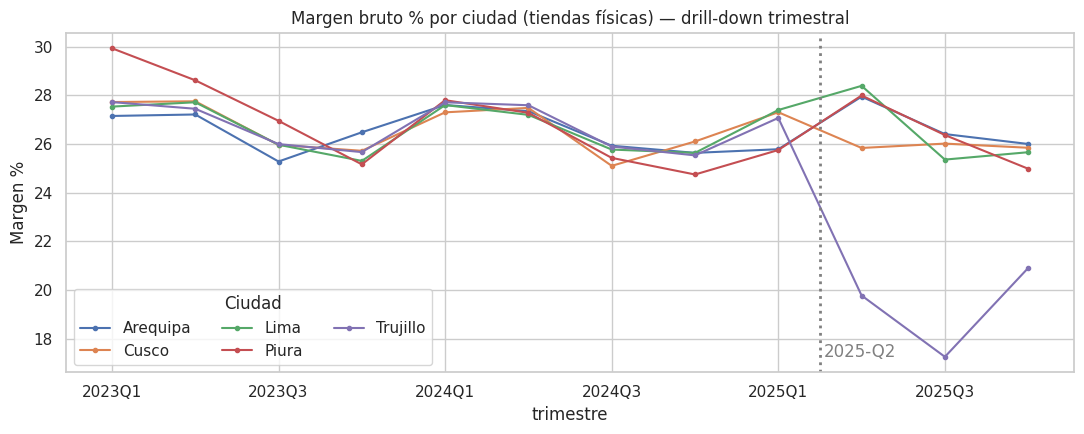

ciudad_tienda  Arequipa  Cusco  Lima  Piura  Trujillo
trimestre                                            
2023Q1            27.20  27.70 27.50  29.90     27.70
2023Q2            27.20  27.80 27.70  28.60     27.50
2023Q3            25.30  26.00 26.00  27.00     26.00
2023Q4            26.50  25.70 25.30  25.20     25.70
2024Q1            27.60  27.30 27.60  27.80     27.70
2024Q2            27.40  27.50 27.20  27.30     27.60
2024Q3            25.90  25.10 25.80  25.40     25.90
2024Q4            25.60  26.10 25.60  24.70     25.50
2025Q1            25.80  27.30 27.40  25.80     27.10
2025Q2            27.90  25.80 28.40  28.00     19.80
2025Q3            26.40  26.00 25.40  26.40     17.20
2025Q4            26.00  25.80 25.70  25.00     20.90


In [10]:
mg_ciudad = (v[v.tipo == "Física"].groupby(["ciudad_tienda", "trimestre"])
             .apply(lambda d: d.margen.sum() / d.monto_total.sum() * 100, include_groups=False)
             .unstack(0))
ax = mg_ciudad.plot(figsize=(11, 4.5), marker="o", ms=3)
ax.axvline(x=list(mg_ciudad.index).index("2025Q2") - 0.5, color="gray", ls=":", lw=2)
ax.annotate("2025-Q2", xy=(list(mg_ciudad.index).index("2025Q2") - 0.45, mg_ciudad.min().min()),
            color="gray")
ax.set_title("Margen bruto % por ciudad (tiendas físicas) — drill-down trimestral")
ax.set_ylabel("Margen %"); ax.legend(title="Ciudad", ncol=3)
plt.tight_layout(); plt.show()
print(mg_ciudad.round(1).to_string())

**Hallazgo del drill-down:** el margen es estable (~25–28%) en todas las plazas **excepto
Trujillo**, que se desploma ~8 puntos porcentuales exactamente a partir de **2025-Q2**.
El problema no es general: está localizado en una ciudad y un momento. Ahora buscamos la
causa descomponiendo las palancas del margen.

In [11]:
# Cohortes pre/post para Trujillo vs. resto (solo tiendas físicas, 2024-Q2 en adelante)
v_fis = v[(v.tipo == "Física") & (v.fecha >= "2024-04-01")].copy()
v_fis["grupo"] = np.where(v_fis.ciudad_tienda == "Trujillo", "Trujillo", "Otras ciudades")
v_fis["periodo_diag"] = np.where(v_fis.fecha >= "2025-04-01", "Post 2025-Q2", "Pre 2025-Q2")

diag = (v_fis.groupby(["grupo", "periodo_diag"])
        .agg(venta=("monto_total", "sum"), margen=("margen", "sum"),
             desc_prom=("descuento_pct", "mean"),
             venta_bruta=("precio_unitario", lambda s: np.nan))  # placeholder
        )
bruta = v_fis.assign(bruto=v_fis.cantidad * v_fis.precio_unitario).groupby(["grupo", "periodo_diag"])["bruto"].sum()
diag["venta_bruta"] = bruta
diag["margen_pct"] = diag.margen / diag.venta * 100
diag["desc_efectivo_pct"] = (1 - diag.venta / diag.venta_bruta) * 100
diag[["margen_pct", "desc_prom", "desc_efectivo_pct"]].round(2)

margen_pct  desc_prom  desc_efectivo_pct
grupo          periodo_diag                                          
Otras ciudades Post 2025-Q2       26.36       3.93               4.27
               Pre 2025-Q2        26.28       3.75               4.10
Trujillo       Post 2025-Q2       19.25      12.99              13.04
               Pre 2025-Q2        26.45       3.72               4.12

In [ ]:
# Descomposición de la caída de margen de Trujillo (post vs. pre) en palancas
tru_pre  = v_fis[(v_fis.grupo == "Trujillo") & (v_fis.periodo_diag == "Pre 2025-Q2")]
tru_post = v_fis[(v_fis.grupo == "Trujillo") & (v_fis.periodo_diag == "Post 2025-Q2")]

def palancas(d):
    bruto = (d.cantidad * d.precio_unitario).sum()
    cant = d.cantidad.sum()
    return pd.Series({
        "margen_pct": d.margen.sum() / d.monto_total.sum() * 100,
        "precio_promedio": bruto / cant,  # precio unitario ponderado por cantidad
        "descuento_efectivo_pct": (1 - d.monto_total.sum() / bruto) * 100,
        "ratio_costo_venta_pct": d.costo_total.sum() / d.monto_total.sum() * 100,
        "pct_electrohogar": d.loc[d.categoria == "Electrohogar", "monto_total"].sum() / d.monto_total.sum() * 100,
    })

comp = pd.DataFrame({"Pre 2025-Q2": palancas(tru_pre), "Post 2025-Q2": palancas(tru_post)})
comp["Δ (post - pre)"] = comp["Post 2025-Q2"] - comp["Pre 2025-Q2"]
print("Trujillo — descomposición de palancas del margen:")
print(comp.round(2).to_string())

# Mezcla de categorías: ¿cambió lo que se vende?
mezcla = (pd.concat([tru_pre.assign(p="Pre"), tru_post.assign(p="Post")])
          .pivot_table(index="categoria", columns="p", values="monto_total", aggfunc="sum")
          .pipe(lambda d: d.div(d.sum(axis=0), axis=1) * 100).round(1))
print("\nMezcla de venta por categoría en Trujillo (%):")
print(mezcla.to_string())


In [13]:
# Costo de almacenamiento (inventario): Trujillo vs. resto, antes y después
inv = inventario.merge(tiendas[["id_tienda", "ciudad"]], on="id_tienda")
inv["grupo"] = np.where(inv.ciudad == "Trujillo", "Trujillo", "Otras ciudades")
inv["periodo_diag"] = np.where(inv.periodo >= "2025-04", "Post 2025-Q2", "Pre 2025-Q2")
costo_alm = (inv.groupby(["grupo", "periodo_diag"])["costo_almacenamiento_unitario"]
             .mean().unstack())
costo_alm["Δ %"] = ((costo_alm["Post 2025-Q2"] / costo_alm["Pre 2025-Q2"] - 1) * 100).round(1)
print("Costo de almacenamiento unitario promedio (S/ por unidad-mes):")
print(costo_alm.round(3).to_string())

Costo de almacenamiento unitario promedio (S/ por unidad-mes):
periodo_diag    Post 2025-Q2  Pre 2025-Q2   Δ %
grupo                                          
Otras ciudades          0.53         0.53 -0.10
Trujillo                0.87         0.53 65.00


**Diagnóstico (causa raíz):** la descomposición aísla el origen de la caída de margen de
Trujillo:

1. **Descuento efectivo:** sube ~+9 pp post 2025-Q2 en Trujillo (de ~4% a ~13%), mientras en las demás
   ciudades permanece estable. Es la **palanca dominante**: cada punto adicional de
   descuento se traslada casi íntegro al margen.
2. **Precio de lista/unitario:** el precio promedio ponderado apenas se mueve entre
   pre y post → la caída **no** viene de una guerra de precios de catálogo, sino del
   descuento sobre el ticket.
3. **Mezcla de categorías:** cambios menores (Electrohogar cede ~4 pp de participación),
   insuficientes para explicar una caída de 7 pp de margen.
4. **Costo de almacenamiento:** además, el costo unitario de almacenamiento de Trujillo
   aumenta ~60–65% desde 2025-04 (las otras plazas no varían), presionando el margen
   operativo del inventario.

**Conclusión diagnóstica:** la caída de margen en Trujillo es consecuencia de una
**política promocional agresiva localizada** (mayor descuento medio) combinada con un
**encarecimiento logístico local**, no de un deterioro del ticket (Notebook 01, H2) ni de
precio o mezcla. Esto delimita el problema prescriptivo de la Parte 4: optimizar la política de
descuentos e inventario de Trujillo bajo sus nuevos costos.

## 6. Conclusiones accionables para la Gerencia

1. **Planificar con el calendario comercial:** julio y diciembre concentran los picos;
   los abastecimientos y turnos deben dimensionarse con el índice estacional por categoría
   y por ciudad (insumo directo del forecast de la Parte 3 y del inventario de la Parte 4).
2. **El negocio ya es ~50% digital:** consolidar la logística de despacho y replantear la
   asignación de inventario entre tiendas y canal virtual.
3. **Gestionar la concentración:** proteger el servicio de los SKUs y clientes del tramo
   80/20; el costo de perder un cliente "campeón" o "en riesgo valioso" es muy superior
   al de un cliente dormido.
4. **Retención dirigida:** los segmentos RFM/K-Means priorizan la inversión: retener
   "en riesgo (valiosos)", desarrollar "regulares/nuevos", no sobreinvertir en "perdidos".
5. **Trujillo requiere intervención inmediata:** revisar la política de descuentos local
   (~+9 pp de descuento efectivo) y renegociar/optimizar el costo de almacenamiento
   (+60%). La Parte 4 cuantifica la política óptima.
